# Strategic Technology Project Portfolio Selection
## Complete Experimental Framework Notebook

This notebook implements the full computational workflow for the project portfolio
selection study.

It is designed for two purposes:

1. **Instructor-friendly verification** through a fast demo mode
2. **Full experimental execution** for the paper

The workflow includes:

- Synthetic instance generation
- Project attribute definition and resource capacity construction
- Greedy baseline algorithm
- Standard Simulated Annealing (SA)
- Adaptive Simulated Annealing (Adaptive SA)
- Experiment execution and results aggregation
- Visual comparison of algorithm performance
- Export of datasets and results for verification

Run all cells to reproduce the workflow.

## Imports

In [ ]:
import numpy as np
import pandas as pd
import random
import os
import seaborn as sns
import time
import shutil
from datetime import datetime
import matplotlib.pyplot as plt
from math import exp
import zipfile

## Configuration

This section defines the global parameters used in the experiments.

The parameter values follow the experimental design described in the paper.

The notebook supports two execution modes:

- **Demo mode**: runs quickly so an instructor can verify the workflow
- **Full mode**: runs the larger experiment settings used in the paper

To switch to the full experimental setting, set `DEMO_MODE = False`.


In [ ]:
# ============================================================
# Execution mode
# ============================================================

DEMO_MODE = True   # Change to False for the full experimental study

# ============================================================
# Configuration
# ============================================================

if DEMO_MODE:
    SIZES = [20]
    INSTANCES_PER_SIZE = 2
    RUNS_PER_INSTANCE = 2
    ITERATIONS = 200
else:
    SIZES = [40, 50, 60]
    INSTANCES_PER_SIZE = 10
    RUNS_PER_INSTANCE = 10
    ITERATIONS = 1000

# Set random seeds to ensure reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Objective parameters
epsilon_values = [1e-6, 1e-4, 1e-3, 1e-2, 0.05]
lambda1 = 1.0
lambda2 = 1.0

# Desired balance targets
tau = {"Short": 3, "Medium": 4, "Long": 3}
iota = {"Exploratory": 3, "Exponential": 4, "Sustaining": 3}

# Project categories
time_categories = ['Short','Medium','Long']
intent_categories = ['Exploratory','Exponential','Sustaining']

# Simulated annealing parameters
T0 = 100.0
alpha = 0.95

# Adaptive SA parameters
alpha_fast = 0.90
alpha_slow = 0.98
W = 50
rho_min = 0.2
rho_max = 0.6
r_max = 0.4
p_swap_high = 0.8

print("Demo mode:" if DEMO_MODE else "Full mode:")
print("Sizes =", SIZES)
print("Instances per size =", INSTANCES_PER_SIZE)
print("Runs per instance =", RUNS_PER_INSTANCE)
print("Iterations =", ITERATIONS)

Full mode:
Sizes = [40, 50, 60]
Instances per size = 10
Runs per instance = 10
Iterations = 1000


## Synthetic Instance Generation

Each project is assigned the attributes used in the mathematical model:

- primary priority score `p_i`
- complementary score `c_i`
- future capability score `f_i`
- budget requirement `b_i`
- staff-hour requirement `h_i`
- time horizon category
- initiative intent category

Resource capacities are defined as 60% of total demand, ensuring that only
a subset of projects can be selected.


In [ ]:
def generate_instance(N):
    data = []
    for i in range(N):
        p = np.random.uniform(30,100)
        c = np.random.uniform(10,40)
        f = np.random.uniform(10,40)
        b = np.random.uniform(5,20)
        h = np.random.uniform(10,40)
        time_cat = random.choice(time_categories)
        intent_cat = random.choice(intent_categories)
        data.append([i,p,c,f,b,h,time_cat,intent_cat])

    df = pd.DataFrame(data, columns=['project_id','p_i','c_i','f_i','b_i','h_i','time','intent'])
    Bmax = 0.6 * df['b_i'].sum()
    Hmax = 0.6 * df['h_i'].sum()
    return df, Bmax, Hmax

## Objective Function and Metrics

In [ ]:
# # Compute portfolio balance penalties
def compute_penalties(selected_df):
    time_counts = {"Short": 0, "Medium": 0, "Long": 0}
    intent_counts = {"Exploratory": 0, "Exponential": 0, "Sustaining": 0}

    for _, row in selected_df.iterrows():
        time_counts[row["time"]] += 1
        intent_counts[row["intent"]] += 1

    Ptime = sum(abs(time_counts[k] - tau[k]) for k in tau)
    Pintent = sum(abs(intent_counts[k] - iota[k]) for k in iota)
    return Ptime, Pintent

# Objective function
def objective(selected_df):
    if selected_df is None or len(selected_df) == 0:
        return -999.0
    V = (
        selected_df["p_i"].sum()
        + epsilon * (selected_df["c_i"].sum() + selected_df["f_i"].sum())
    )
    Ptime, Pintent = compute_penalties(selected_df)
    return V - lambda1 * Ptime - lambda2 * Pintent

# Evaluation metrics (objective value and penalties)
def metrics(selected_df):
    if selected_df is None or len(selected_df) == 0:
        return -999.0, np.nan, np.nan

    Ptime, Pintent = compute_penalties(selected_df)
    return objective(selected_df), Ptime, Pintent


## Greedy Baseline

In [ ]:
# select projects in descending order of primary score
# while respecting budget and staff capacity constraints

def greedy(df, Bmax, Hmax):
    df_sorted = df.sort_values(by="p_i", ascending=False)

    budget = 0.0
    staff = 0.0
    selected_rows = []

    for _, row in df_sorted.iterrows():
        if budget + row["b_i"] <= Bmax and staff + row["h_i"] <= Hmax:
            selected_rows.append(row)
            budget += row["b_i"]
            staff += row["h_i"]

    return pd.DataFrame(selected_rows)


## Solution Representation and Neighborhood Moves

We represent a portfolio solution as a binary vector where:

- `1` means the project is selected
- `0` means the project is not selected

It includes feasibility checks, a repair procedure for constraint violations, and the flip and swap moves used to generate neighboring solutions.


In [ ]:
def df_to_vector(selected_df, df):
    x = np.zeros(len(df), dtype=int)
    if selected_df is not None and len(selected_df) > 0:
        x[selected_df["project_id"].astype(int).values] = 1
    return x

def vector_to_df(x, df):
    return df.loc[x == 1].copy()

# Check whether a solution satisfies resource constraints
def is_feasible(x, df, Bmax, Hmax):
    selected = df.loc[x == 1]
    return (selected["b_i"].sum() <= Bmax) and (selected["h_i"].sum() <= Hmax)

# Repair infeasible solution by randomly removing projects
def repair_vector(x, df, Bmax, Hmax):
    x = x.copy()
    while not is_feasible(x, df, Bmax, Hmax):
        selected_idx = np.where(x == 1)[0]
        if len(selected_idx) == 0:
            break
        remove_idx = random.choice(list(selected_idx))
        x[remove_idx] = 0
    return x

# Neighborhood move: flip selection status of one project
def flip_move(x):
    y = x.copy()
    idx = random.randint(0, len(x) - 1)
    y[idx] = 1 - y[idx]
    return y

# Neighborhood move: swap one selected and one non-selected project
def swap_move(x):
    y = x.copy()
    selected = np.where(x == 1)[0]
    non_selected = np.where(x == 0)[0]

    if len(selected) == 0 or len(non_selected) == 0:
        return flip_move(x)

    i = random.choice(list(selected))
    j = random.choice(list(non_selected))

    y[i] = 0
    y[j] = 1

    return y


## Standard Simulated Annealing (SA)

This algorithm uses a fixed cooling schedule and a simple flip neighborhood.


In [ ]:
def simulated_annealing(df, Bmax, Hmax, return_trace=False):
    current_df = greedy(df, Bmax, Hmax)
    x_current = df_to_vector(current_df, df)
    current_val = objective(current_df)

    x_best = x_current.copy()
    best_val = current_val

    T = T0
    trace = []

    for it in range(ITERATIONS):
        y = flip_move(x_current)
        y = repair_vector(y, df, Bmax, Hmax)

        cand_df = vector_to_df(y, df)
        cand_val = objective(cand_df)
        delta = cand_val - current_val

        if delta >= 0 or random.random() < exp(delta / max(T, 1e-9)):
            x_current = y
            current_val = cand_val

        if current_val > best_val:
            x_best = x_current.copy()
            best_val = current_val

        if return_trace and (it % 10 == 0):
            trace.append(best_val)

        T *= alpha

    best_df = vector_to_df(x_best, df)
    if return_trace:
        return best_df, best_val, trace
    return best_df, best_val

## Adaptive Simulated Annealing (Adaptive SA)

This algorithm extends standard simulated annealing with two adaptive mechanisms:

1. **Adaptive cooling**
   - temperature updates depend on the recent acceptance rate

2. **Adaptive neighborhood mixing**
   - swap moves become more likely when infeasible candidates occur frequently


In [ ]:

def adaptive_sa(df, Bmax, Hmax, return_trace=False):
    current_df = greedy(df, Bmax, Hmax)
    x_current = df_to_vector(current_df, df)
    current_val = objective(current_df)

    x_best = x_current.copy()
    best_val = current_val

    T = T0
    trace = []

    accepted_in_window = 0
    repaired_in_window = 0
    p_swap = 0.5
    no_improve = 0

    for it in range(ITERATIONS):

        # Choose move type with small forced exploration
        r_move = random.random()
        if r_move < 0.05:
            y = flip_move(x_current)
        elif r_move < p_swap:
            y = swap_move(x_current)
        else:
            y = flip_move(x_current)

        # Feasibility check and repair
        feasible_before_repair = is_feasible(y, df, Bmax, Hmax)
        if not feasible_before_repair:
            repaired_in_window += 1
            y = repair_vector(y, df, Bmax, Hmax)

        cand_df = vector_to_df(y, df)
        cand_val = objective(cand_df)
        delta = cand_val - current_val

        # SA acceptance rule
        if delta >= 0 or random.random() < exp(delta / max(T, 1e-9)):
            x_current = y
            current_val = cand_val
            accepted_in_window += 1

        # Best solution tracking
        if current_val > best_val:
            x_best = x_current.copy()
            best_val = current_val
            no_improve = 0
        else:
            no_improve += 1

        # Reheating if stuck
        if no_improve > W:
            T = T0 * 0.5
            no_improve = 0

        if return_trace and (it % 10 == 0):
            trace.append(best_val)

        # Adaptive temperature control
        if (it + 1) % (2 * W) == 0:
            rho = accepted_in_window / W
            r = repaired_in_window / W

            if rho > rho_max:
                T *= alpha_fast
            elif rho < rho_min:
                T *= alpha_slow
            else:
                T *= alpha

            # Smooth adaptation of swap probability
            if r > r_max:
                p_swap = min(0.9, p_swap + 0.05)
            elif r < r_max / 2:
                p_swap = max(0.1, p_swap - 0.05)

            accepted_in_window = 0
            repaired_in_window = 0

    best_df = vector_to_df(x_best, df)
    if return_trace:
        return best_df, best_val, trace
    return best_df, best_val


## Generate and Save All Instances

For each problem size, multiple instances are created using the instance generation function and saved for later use during the optimization experiments.
stores them in memory, and saves them as CSV files in the `instances/` folder.


In [ ]:
instances = {}
instance_summary = []

for N in SIZES:
    for k in range(INSTANCES_PER_SIZE):
        df, Bmax, Hmax = generate_instance(N)

        instances[(N, k)] = (df, Bmax, Hmax)

        instance_summary.append({
            "Size": N,
            "Instance": k + 1,
            "B_max": Bmax,
            "H_max": Hmax
        })

instance_summary_df = pd.DataFrame(instance_summary)
instance_summary_df


,Size,Instance,B_max,H_max
0,40,1,290.796909,573.639266
1,40,2,312.600267,558.477601
2,40,3,325.245901,596.395176
3,40,4,289.655794,568.129165
4,40,5,296.487093,544.213979
5,40,6,318.094681,592.634045
6,40,7,300.048503,605.435947
7,40,8,275.847910,690.133973
8,40,9,295.829349,587.667493
9,40,10,302.401939,629.361611


### Saving and Reloading Experiment Results

To avoid rerunning computationally expensive experiments when reopening the notebook, the experiment results are saved to disk.  

In [ ]:
RESULTS_FILE = "saved_experiment_results.csv"

if os.path.exists(RESULTS_FILE):
    print("Loading saved experiment results...")
    results_df = pd.read_csv(RESULTS_FILE)
    results = results_df.values.tolist()
    skip_experiments = True
else:
    print("No saved results found. Experiments will run.")
    skip_experiments = False

No saved results found. Experiments will run.


## Experiment Execution

In [ ]:
results = []
convergence_data = []

for epsilon in epsilon_values:

    print(f"\nRunning experiments with epsilon = {epsilon}")

    for (N, k), (df, Bmax, Hmax) in instances.items():
        print(f"Running instance size {N}, instance {k+1}")

        # Greedy baseline
        start = time.time()
        greedy_df = greedy(df, Bmax, Hmax)
        greedy_runtime = time.time() - start
        greedy_obj, greedy_time_dev, greedy_intent_dev = metrics(greedy_df)
        results.append([N, k+1, epsilon, "Greedy", greedy_obj, greedy_time_dev, greedy_intent_dev, greedy_runtime])

        # Standard SA and Adaptive SA
        for run_id in range(1, RUNS_PER_INSTANCE + 1):

            start = time.time()
            sa_df, sa_obj, sa_trace = simulated_annealing(df, Bmax, Hmax, return_trace=True)
            sa_runtime = time.time() - start
            sa_obj, sa_time_dev, sa_intent_dev = metrics(sa_df)

            results.append([N, k+1, epsilon, "SA", sa_obj, sa_time_dev, sa_intent_dev, sa_runtime])
            convergence_data.append([N, "SA", run_id, sa_trace])

            start = time.time()
            asa_df, asa_obj, asa_trace = adaptive_sa(df, Bmax, Hmax, return_trace=True)
            asa_runtime = time.time() - start
            asa_obj, asa_time_dev, asa_intent_dev = metrics(asa_df)

            results.append([N, k+1, epsilon, "Adaptive SA", asa_obj, asa_time_dev, asa_intent_dev, asa_runtime])
            convergence_data.append([N, "Adaptive SA", run_id, asa_trace])

print("Experiment execution completed.")


Running experiments with epsilon = 1e-06
Running instance size 40, instance 1
Running instance size 40, instance 2
Running instance size 40, instance 3
Running instance size 40, instance 4
Running instance size 40, instance 5
Running instance size 40, instance 6
Running instance size 40, instance 7
Running instance size 40, instance 8
Running instance size 40, instance 9
Running instance size 40, instance 10
Running instance size 50, instance 1
Running instance size 50, instance 2
Running instance size 50, instance 3
Running instance size 50, instance 4
Running instance size 50, instance 5
Running instance size 50, instance 6
Running instance size 50, instance 7
Running instance size 50, instance 8
Running instance size 50, instance 9
Running instance size 50, instance 10
Running instance size 60, instance 1
Running instance size 60, instance 2
Running instance size 60, instance 3
Running instance size 60, instance 4
Running instance size 60, instance 5
Running instance size 60, insta

In [ ]:
# Save experiment results for reuse
RESULTS_FILE = "saved_experiment_results.csv"

results_df = pd.DataFrame(
    results,
    columns=[
        "Size",
        "Instance",
        "Epsilon",
        "Algorithm",
        "Objective",
        "TimeDev",
        "IntentDev",
        "Runtime"
    ]
)

results_df.to_csv(RESULTS_FILE, index=False)

print("Experiment results saved to:", RESULTS_FILE)

Experiment results saved to: saved_experiment_results.csv


## 🧰 Results Aggregation
This section aggregates the raw experiment results.

It reports the average objective value, standard deviation, balance deviations, and runtime for each algorithm and problem size.

In [ ]:
# Build results dataframe
results_df = pd.DataFrame(
    results,
    columns=[
        "Size",
        "Instance",
        "Epsilon",
        "Algorithm",
        "Objective",
        "TimeDev",
        "IntentDev",
        "Runtime"
    ]
)

# Aggregate results
summary = results_df.groupby(["Size", "Algorithm"]).agg(
    Avg_Objective=("Objective", "mean"),
    Std_Objective=("Objective", "std"),
    Avg_TimeDev=("TimeDev", "mean"),
    Avg_IntentDev=("IntentDev", "mean"),
    Avg_Runtime=("Runtime", "mean")
).reset_index()

# Determine best algorithm overall
best_algorithm = results_df.groupby("Algorithm")["Objective"].mean().idxmax()
print("Best algorithm (by average objective):", best_algorithm)

# Overall statistics
algo_stats = results_df.groupby("Algorithm")["Objective"].agg(["mean", "std"]).reset_index()
print("\nOverall algorithm statistics:")
print(algo_stats)

# Build publication-style table
paper_table = summary.copy()

paper_table["Objective (mean±std)"] = (
    paper_table["Avg_Objective"].round(2).astype(str)
    + " ± "
    + paper_table["Std_Objective"].round(2).astype(str)
)

paper_table = paper_table[
    [
        "Size",
        "Algorithm",
        "Avg_Objective",
        "Std_Objective",
        "Objective (mean±std)",
        "Avg_TimeDev",
        "Avg_IntentDev",
        "Avg_Runtime"
    ]
]

# Sort algorithms by performance within each size
paper_table = paper_table.sort_values(
    by=["Size", "Avg_Objective"],
    ascending=[True, False]
)

paper_table = paper_table.drop(columns=["Avg_Objective", "Std_Objective"])

# Display table
paper_table


Best algorithm (by average objective): SA

Overall algorithm statistics:
     Algorithm         mean         std
0  Adaptive SA  2297.698194  360.941794
1       Greedy  2297.392425  362.043435
2           SA  2331.532327  365.005551


,Size,Algorithm,Objective (mean±std),Avg_TimeDev,Avg_IntentDev,Avg_Runtime
2,40,SA,1895.69 ± 98.66,14.776,14.916,2.358653
0,40,Adaptive SA,1865.24 ± 100.77,13.622,13.822,2.227704
1,40,Greedy,1864.92 ± 101.74,13.600,13.800,0.004027
5,50,SA,2339.9 ± 96.7,21.240,21.240,2.620682
3,50,Adaptive SA,2311.01 ± 101.01,20.114,20.114,2.468472
4,50,Greedy,2310.73 ± 101.91,20.100,20.100,0.004240
8,60,SA,2759.01 ± 87.31,26.972,26.972,2.930131
6,60,Adaptive SA,2716.85 ± 85.97,25.434,25.434,2.767155
7,60,Greedy,2716.52 ± 86.91,25.400,25.400,0.004995


### 🧰 Figure and Table Export Helpers

Helper functions to save figures (`paper_figures/`) and tables (`paper_tables/`) for use in the manuscript.

In [ ]:
# Utilities for exporting figures and tables

# Directory for manuscript figures
FIG_DIR = "paper_figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_figure(name):
    pdf_path = os.path.join(FIG_DIR, f"{name}.pdf")
    png_path = os.path.join(FIG_DIR, f"{name}.png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"Figure saved: {pdf_path}")


# Directory for manuscript tables
TABLE_DIR = "paper_tables"
os.makedirs(TABLE_DIR, exist_ok=True)

def save_table_latex(df, name):
    path = os.path.join(TABLE_DIR, f"{name}.tex")

    df.to_latex(
        path,
        index=False,
        float_format="%.3f",
        caption=name.replace("_", " ").title(),
        label=f"tab:{name}"
    )

    print(f"Table saved: {path}")

In [ ]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

LINE_WIDTH = 2.5
MARKER_SIZE = 7
EDGE_WIDTH = 1.5

color_map = {
    "Adaptive SA": "#ff7f0e",
    "Greedy": "#7f7f7f",
    "SA": "#1f77b4"
}

marker_map = {
    "Adaptive SA": "^",
    "Greedy": "o",
    "SA": "s"
}

linestyle_map = {
    "Adaptive SA": "--",
    "Greedy": ":",
    "SA": "-"
}

 ## ⭐ Algorithm Performance Comparison
Main algorithm comparison figure

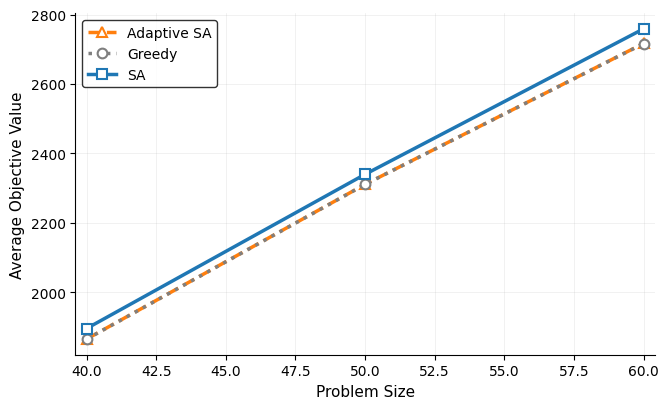

In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))

color_map = {
    "Adaptive SA": "#ff7f0e",
    "Greedy": "#7f7f7f",
    "SA": "#1f77b4"
}

marker_map = {
    "Adaptive SA": "^",
    "Greedy": "o",
    "SA": "s"
}

linestyle_map = {
    "Adaptive SA": "--",
    "Greedy": ":",
    "SA": "-"
}

for algo in ["Adaptive SA", "Greedy", "SA"]:
    subset = summary[summary["Algorithm"] == algo]

    ax.plot(
        subset["Size"],
        subset["Avg_Objective"],
        color=color_map[algo],
        marker=marker_map[algo],
        linestyle=linestyle_map[algo],
        linewidth=2.5,
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=1.5,
        label=algo
    )

ax.set_xlabel("Problem Size", fontsize=11)
ax.set_ylabel("Average Objective Value", fontsize=11)

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="best", fontsize=10, frameon=True, edgecolor="black")

ax.margins(x=0.02, y=0.05)

plt.tight_layout()

fig.savefig("algorithm_performance.png", dpi=300, bbox_inches="tight")

plt.show()

## ⭐ Convergence Comparison

---


Shows Adaptive SA improves convergence behavior.

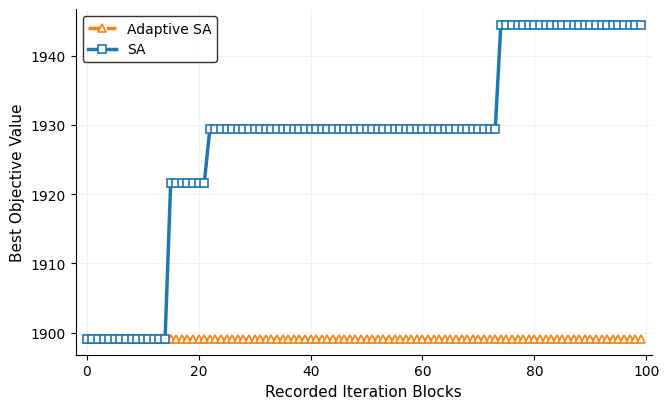

In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))

for algo in ["Adaptive SA", "SA"]:
    trace = asa_trace if algo == "Adaptive SA" else sa_trace

    ax.plot(
        range(len(trace)),
        trace,
        color=color_map[algo],
        marker=marker_map[algo],
        linestyle=linestyle_map[algo],
        linewidth=LINE_WIDTH,
        markersize=6,
        markerfacecolor="white",
        markeredgewidth=1.2,
        label=algo
    )

ax.set_xlabel("Recorded Iteration Blocks")
ax.set_ylabel("Best Objective Value")

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="best", frameon=True, edgecolor="black")
ax.margins(x=0.02, y=0.05)

plt.tight_layout()
fig.savefig("convergence_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## ⭐ Runtime Scaling
Shows computational efficiency

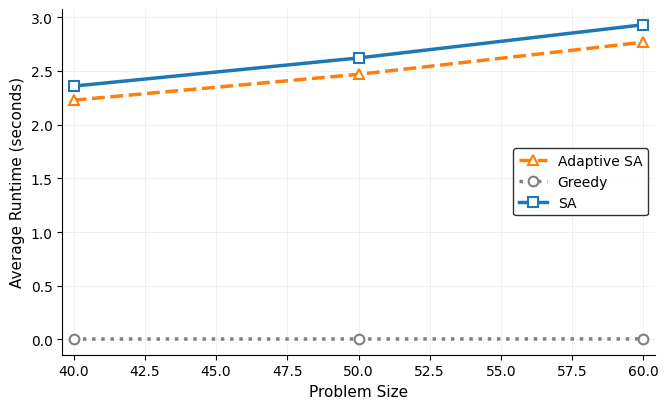

In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))

for algo in ["Adaptive SA", "Greedy", "SA"]:
    subset = summary[summary["Algorithm"] == algo]

    ax.plot(
        subset["Size"],
        subset["Avg_Runtime"],
        color=color_map[algo],
        marker=marker_map[algo],
        linestyle=linestyle_map[algo],
        linewidth=LINE_WIDTH,
        markersize=MARKER_SIZE,
        markerfacecolor="white",
        markeredgewidth=EDGE_WIDTH,
        label=algo
    )

ax.set_xlabel("Problem Size")
ax.set_ylabel("Average Runtime (seconds)")

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="best", frameon=True, edgecolor="black")
ax.margins(x=0.02, y=0.05)

plt.tight_layout()
fig.savefig("runtime_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

## 🧪 Best Algorithm per Problem Size
Good table for discussion but redundant if the plot is clear.:

In [ ]:
# Identify the best algorithm per problem size
best_by_size = summary.loc[summary.groupby("Size")["Avg_Objective"].idxmax()]
best_by_size

# Export the summary table to LaTeX
save_table_latex(summary, "algorithm_performance_summary")


Table saved: paper_tables/algorithm_performance_summary.tex


## ⭐ Impact of ε on Objective
Core sensitivity analysis

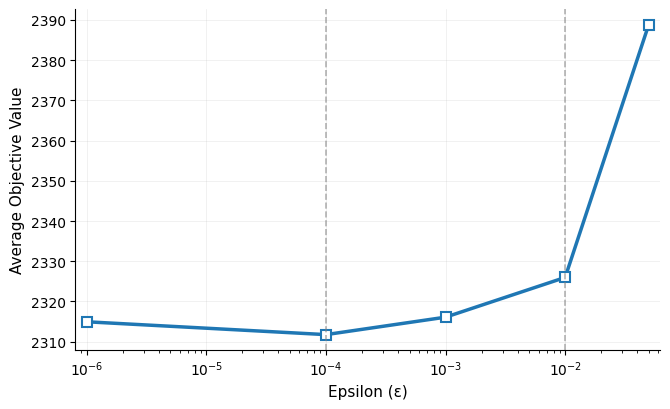

In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))

ax.plot(
    epsilon_summary["Epsilon"],
    epsilon_summary["Objective"],
    color=color_map["SA"],
    marker="s",
    linestyle="-",
    linewidth=LINE_WIDTH,
    markersize=MARKER_SIZE,
    markerfacecolor="white",
    markeredgewidth=EDGE_WIDTH
)

ax.axvline(1e-4, linestyle="--", color="gray", linewidth=1.2, alpha=0.6)
ax.axvline(1e-2, linestyle="--", color="gray", linewidth=1.2, alpha=0.6)

ax.set_xscale("log")

ax.set_xlabel("Epsilon (ε)")
ax.set_ylabel("Average Objective Value")

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.margins(x=0.02, y=0.05)

plt.tight_layout()
fig.savefig("impact_epsilon_objective.png", dpi=300, bbox_inches="tight")
plt.show()

## ⭐ Portfolio Balance Stability
This figure illustrates the trade-off between time-horizon balance and strategic-intent balance across different values of ε using the SA algorithm. Each point corresponds to the average balance deviations obtained by SA for a specific ε value, highlighting how the weighting parameter influences portfolio structure.

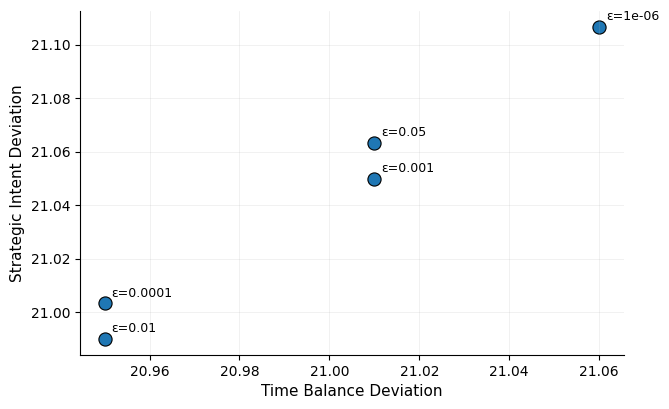

In [ ]:

fig, ax = plt.subplots(figsize=(6.8, 4.2))

ax.scatter(
    pareto_df["TimeDev"],
    pareto_df["IntentDev"],
    s=90,
    color=color_map["SA"],
    edgecolor="black",
    linewidth=0.8
)

for _, row in pareto_df.iterrows():
    ax.annotate(
        f"ε={row['Epsilon']:g}",
        (row["TimeDev"], row["IntentDev"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_xlabel("Time Balance Deviation")
ax.set_ylabel("Strategic Intent Deviation")

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.margins(x=0.05, y=0.05)

plt.tight_layout()
fig.savefig("balance_stability.png", dpi=300, bbox_inches="tight")
plt.show()

## ⭐ Balance Trade-off Visualization
Illustrates Trade-off between time balance deviation and strategic intent deviation under simulated annealing (SA)



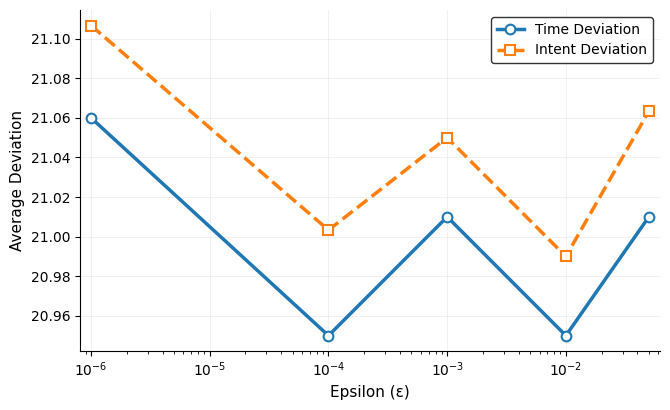

In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))

ax.plot(
    epsilon_summary["Epsilon"],
    epsilon_summary["TimeDev"],
    color="#1f77b4",
    marker="o",
    linestyle="-",
    linewidth=LINE_WIDTH,
    markersize=MARKER_SIZE,
    markerfacecolor="white",
    markeredgewidth=EDGE_WIDTH,
    label="Time Deviation"
)

ax.plot(
    epsilon_summary["Epsilon"],
    epsilon_summary["IntentDev"],
    color="#ff7f0e",
    marker="s",
    linestyle="--",
    linewidth=LINE_WIDTH,
    markersize=MARKER_SIZE,
    markerfacecolor="white",
    markeredgewidth=EDGE_WIDTH,
    label="Intent Deviation"
)

ax.set_xscale("log")

ax.set_xlabel("Epsilon (ε)")
ax.set_ylabel("Average Deviation")

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="best", frameon=True, edgecolor="black")
ax.margins(x=0.02, y=0.05)

plt.tight_layout()
fig.savefig("tradeoff_time_vs_intent.png", dpi=300, bbox_inches="tight")
plt.show()

## 🧪 Objective distribution (boxplots)

Demonstrates algorithm robustness (shows variability across runs)

/tmp/ipykernel_6119/1939775849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


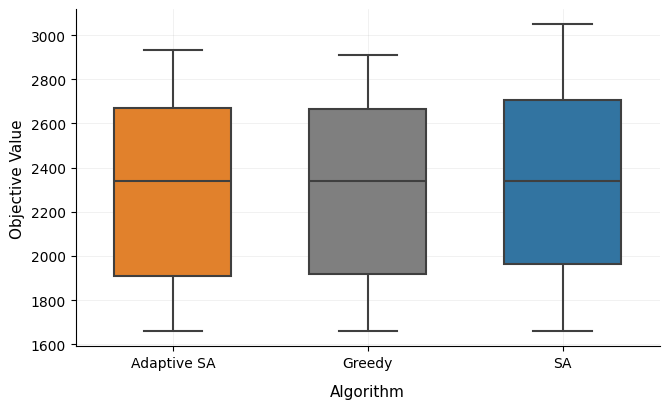

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(6.8, 4.2))

sns.boxplot(
    data=results_df,
    x="Algorithm",
    y="Objective",
    order=["Adaptive SA", "Greedy", "SA"],
    palette=color_map,
    width=0.6,
    linewidth=1.5,
    ax=ax
)

ax.set_xlabel("Algorithm", labelpad=10)
ax.set_ylabel("Objective Value")

ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig("objective_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 🧰 Experiment Results Export
This section exports experiment results, tables, and figures for reproducibility and manuscript preparation.

In [ ]:
# Create results folder
results_folder = "results"
os.makedirs(results_folder, exist_ok=True)

# Save experiment outputs
instance_summary_df.to_csv(f"{results_folder}/instance_summary.csv", index=False)
results_df.to_csv(f"{results_folder}/experiment_results_raw.csv", index=False)
summary.to_csv(f"{results_folder}/experiment_results_summary.csv", index=False)

# Archive instances if they exist
if os.path.exists("instances"):
    shutil.make_archive(f"{results_folder}/portfolio_instances", "zip", "instances")
    print("Instances folder archived.")
else:
    print("No instances folder found. Skipping archive.")

print("\nExport completed.")
print("Saved files in:", results_folder)
print("- instance_summary.csv")
print("- experiment_results_raw.csv")
print("- experiment_results_summary.csv")
print("- portfolio_instances.zip (if instances exist)")

No instances folder found. Skipping archive.

Export completed.
Saved files in: results
- instance_summary.csv
- experiment_results_raw.csv
- experiment_results_summary.csv
- portfolio_instances.zip (if instances exist)


In [ ]:
# Bundle all figures and tables into a single archive for sharing
with zipfile.ZipFile("paper_material.zip", "w") as z:
    for root, dirs, files in os.walk("paper_figures"):
        for file in files:
            z.write(os.path.join(root, file))

    for root, dirs, files in os.walk("paper_tables"):
        for file in files:
            z.write(os.path.join(root, file))

print("Paper material exported to paper_material.zip")

Paper material exported to paper_material.zip


## Notebook overview
The notebook is organized into three layers:

**Legend for section symbols**

⭐ = Figure or table used in the paper  
🧪 = Supporting / exploratory analysis  
🧰 = Utility or infrastructure code

---

**Main results**

⭐ Algorithm performance comparison  
⭐ Convergence comparison  
⭐ Runtime scaling  
⭐ Impact of ε on objective  
⭐ Portfolio balance stability  
⭐ Balance trade-off visualization  

---

**Supporting analysis**

🧪 Best Algorithm per Problem Size  
🧪 Objective distribution (boxplots)  

---

**Utilities**

🧰 Results aggregation  
🧰 Figure and Table Export Helpers  
🧰 Experiment Results Export

# ---
### End of Notebook